<a href="https://colab.research.google.com/github/RealRohitDudi/Data_Science_Notes/blob/main/session_16_tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###`Q-1:` Write a program to create an empty series.

In [1]:
# code here
import numpy as np
import pandas as pd
series = pd.Series()

###`Q-2:` Write a Pandas program to add, subtract, multiple and divide two Pandas Series.

In [5]:
# code here
series1 = pd.Series([2,4,6,8,10])
series2 = pd.Series([3,6,9,12,15])
print("Addition: \n",series1 + series2)
print("subtract: \n",series2 - series1)
print("multile: \n",series1 * series2)
print("division: \n",series2 / series1)


Addition: 
 0     5
1    10
2    15
3    20
4    25
dtype: int64
subtract: 
 0    1
1    2
2    3
3    4
4    5
dtype: int64
multile: 
 0      6
1     24
2     54
3     96
4    150
dtype: int64
division: 
 0    1.5
1    1.5
2    1.5
3    1.5
4    1.5
dtype: float64


###`Q-3` Write a Pandas program to compare the elements of the two Pandas Series.
Sample Series: [2, 4, 6, 8, 10], [1, 3, 5, 7, 10]



In [7]:
# code here
sample1 = pd.Series( [2, 4, 6, 8, 10] )
sample2 = pd.Series( [1, 3, 5, 7, 10] )
print("Equals: \n",sample1 == sample2)

Equals: 
 0    False
1    False
2    False
3    False
4     True
dtype: bool


###`Q-5.`Write a function to change the data type of given a column or a Series. Function takes series and data type as input, returns the converted series.
```
series = pd.Series([1,2,'Python', 2.0, True, 100])
change to float type data
```
Note: Read about pd.to_numeric()

In [14]:
# code here
series = pd.Series([1,2,'Python', 2.0, True, 100])


def change_data_type(series, new_data_type):
  series = pd.to_numeric(series, errors='coerce')
  # converted = series.astype(new_data_type)
  return series

change_data_type(series,'int')

,0
0,1.0
1,2.0
2,NaN
3,2.0
4,1.0
5,100.0


Download data - https://drive.google.com/file/d/1LRhXwbEodeWXtzPhJCX0X9Lf_BECzvqb/view?usp=share_link
All Batsman runs series in IPL 2008 to 2022.

Below questions are based on this data.

###`Q-6` Find top 10 most run getter from the series.

In [39]:
# code here
runs = pd.read_csv('/content/batsman_runs_series.csv',index_col='batter')['batsman_run']
print(f"Object type: {type(runs)}")

runs.sort_values(ascending=False).head(25)

Object type: <class 'pandas.core.series.Series'>


,batsman_run
batter,
V Kohli,6634
S Dhawan,6244
DA Warner,5883
RG Sharma,5881
SK Raina,5536
AB de Villiers,5181
CH Gayle,4997
MS Dhoni,4978
RV Uthappa,4954


###`Q-7` No of players having runs above 3000

In [51]:
# code here
top_runs = runs[runs>3000].count
print(f"No of players having runs above 3000: {top_runs()}")

No of players having runs above 3000: 20


###`Q-8` No of players having runs above mean value?

In [49]:
# code here
above_mean_runs = runs[runs>runs.mean()].count()
mean_value= runs.mean()
print("mean value:",mean_value)
print(f"No of players having runs above mean value: {above_mean_runs}")

mean value: 464.42809917355373
No of players having runs above mean value: 128


Download data - https://drive.google.com/file/d/1QZuZ5bypUInfVvarHACLAi8tXXHvb8xd/view?usp=share_link

file name - items.csv



###`Q-9`
    i. Read `items.csv` making `item_name` as index.
    ii. Show no of nan values
    ii. Item price is given in $, so convert it to rupees without currency symbol.
    iii. Make data type of newly made series as float.
    iv. Fill nan with mean of the series


How csv file looks

```
item_name	item_price
Chips and Fresh Tomato Salsa	$2.39
Izze	$3.39
Nantucket Nectar	$3.39
Chips and Tomatillo-Green Chili Salsa	$2.39
Chicken Bowl	$16.98

```

In [76]:
# code here
items = pd.read_csv('/content/items.csv',index_col='item_name')['item_price']

nan_count = items.isna().sum()
print(f"No of nan values: {nan_count}")

# Remove '$' sign and convert to float by reassigning to items
items = items.str.replace('$', '', regex=False).astype(float)

# Convert to rupees by reassigning to items
items = items * 93.28

items = items.fillna(items.mean())

print(items.head())

No of nan values: 50
item_name
Chips and Fresh Tomato Salsa              222.9392
Izze                                      316.2192
Nantucket Nectar                          316.2192
Chips and Tomatillo-Green Chili Salsa     222.9392
Chicken Bowl                             1583.8944
Name: item_price, dtype: float64


###`Q-10`:
    i. Find mean price
    ii. Find 30th and 6th percentile value
    iii. Plot Histogram on price with bin size 50
    iv. No of items price lies between [1000 to 2000]



mean price is:  696.1515779527559
6th percentile is:  116.6
30th percentile is:  415.096
No of items price lies between [1000 to 2000]:  1066


,item_price
item_name,
Chips and Fresh Tomato Salsa,222.939200
Izze,316.219200
Nantucket Nectar,316.219200
Chips and Tomatillo-Green Chili Salsa,222.939200
Chicken Bowl,1583.894400
Chicken Bowl,1024.214400
Side of Chips,696.151578
Steak Burrito,1096.040000
Steak Soft Tacos,696.151578


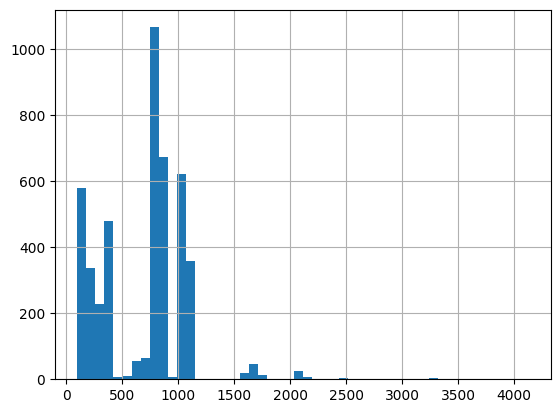

In [95]:
# code here
import numpy as np

prices = np.array(items.values)

mean_price = items.mean()

print("mean price is: ",mean_price)
print("6th percentile is: ",np.percentile(prices,6))
print("30th percentile is: ",np.percentile(prices,30))

items.hist(bins=50)

between_1000_2000 = items[(items >= 1000) & (items <= 2000)].count()
print("No of items price lies between [1000 to 2000]: ",between_1000_2000)

items.clip(1000,2000)
items.head(20)